# Churn Prediction
- Feature engineering (compute R/F/M scores)
- Label encoding categorical features
- Logistic Regression baseline
- Random Forest classifier
- Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC
- Feature importance
- Model comparison & selection
- Save models

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score, precision_score, recall_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Data

In [2]:
customers = pd.read_csv('../data/Customers.csv')
print(f"Shape: {customers.shape}")
print("Columns:", list(customers.columns))
print(f"Churn distribution:\n{customers['churn'].value_counts()}")
print(f"Churn rate: {customers['churn'].mean()*100:.1f}%")

Shape: (5500, 23)
Columns: ['customer_id', 'age', 'gender', 'state', 'city', 'income_level', 'top_category', 'device_type', 'acquisition_channel', 'loyalty_tier', 'session_frequency', 'avg_session_duration', 'cart_abandonment_rate', 'returns_ratio', 'discount_dependency', 'avg_order_value', 'frequency', 'seasonal_spike_factor', 'monetary_value', 'time_between_purchases', 'recency', 'net_promoter_score', 'churn']
Churn distribution:
churn
0    4345
1    1155
Name: count, dtype: int64
Churn rate: 21.0%


## 3. Feature Engineering — Compute RFM Scores

In [3]:
customers['R_score'] = pd.qcut(customers['recency'], q=5, labels=[5,4,3,2,1]).astype(int)
customers['F_score'] = pd.qcut(customers['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
customers['M_score'] = pd.qcut(customers['monetary_value'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
customers['RFM_Score'] = customers['R_score'] + customers['F_score'] + customers['M_score']

print("RFM scores computed")
customers[['R_score','F_score','M_score','RFM_Score']].describe()

RFM scores computed


,R_score,F_score,M_score,RFM_Score
count,5500.000000,5500.000000,5500.000000,5500.000000
mean,3.006000,3.000000,3.000000,9.006000
std,1.419912,1.414342,1.414342,3.802326
min,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,2.000000,5.000000
50%,3.000000,3.000000,3.000000,9.000000
75%,4.000000,4.000000,4.000000,12.000000
max,5.000000,5.000000,5.000000,15.000000


## 4. Feature Selection & Encoding

In [4]:
CATEGORICAL = ['gender','income_level','loyalty_tier','device_type',
               'discount_dependency','acquisition_channel','top_category']

NUMERIC = ['age','session_frequency','avg_session_duration','cart_abandonment_rate',
           'returns_ratio','avg_order_value','frequency','seasonal_spike_factor',
           'monetary_value','time_between_purchases','recency','net_promoter_score',
           'R_score','F_score','M_score','RFM_Score']

FEATURE_COLS = NUMERIC + CATEGORICAL
TARGET = 'churn'

churn_df = customers[FEATURE_COLS + [TARGET]].copy()

label_encoders = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    churn_df[col] = le.fit_transform(churn_df[col])
    label_encoders[col] = le

print("Features selected & encoded")
print(f"Total features: {len(FEATURE_COLS)}")
churn_df.head(3)

Features selected & encoded
Total features: 23


,age,session_frequency,avg_session_duration,cart_abandonment_rate,returns_ratio,avg_order_value,frequency,seasonal_spike_factor,monetary_value,time_between_purchases,...,M_score,RFM_Score,gender,income_level,loyalty_tier,device_type,discount_dependency,acquisition_channel,top_category,churn
0,57,25,3.2,0.17,0.34,4268,8,1.13,38583,46,...,4,12,0,0,1,1,2,3,3,0
1,57,5,14.2,0.31,0.08,1415,2,1.11,3141,182,...,2,6,0,2,0,0,0,3,0,0
2,34,13,4.5,0.14,0.06,16803,8,1.21,162653,46,...,5,14,1,2,1,1,2,2,2,0


## 5. Train-Test Split & Scaling

In [5]:
X = churn_df.drop(columns=[TARGET])
y = churn_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler_churn = StandardScaler()
X_train_scaled = scaler_churn.fit_transform(X_train)
X_test_scaled  = scaler_churn.transform(X_test)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")

Train : (4400, 23)  |  Test : (1100, 23)
Train churn rate: 21.0%  |  Test churn rate: 21.0%


## 6. Logistic Regression

In [6]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       869
           1       0.90      0.98      0.94       231

    accuracy                           0.97      1100
   macro avg       0.95      0.98      0.96      1100
weighted avg       0.98      0.97      0.97      1100

ROC-AUC: 0.9981


## 7. Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       869
           1       0.88      0.92      0.90       231

    accuracy                           0.96      1100
   macro avg       0.93      0.94      0.94      1100
weighted avg       0.96      0.96      0.96      1100

ROC-AUC: 0.9912


## 8. Model Evaluation — Visualisations

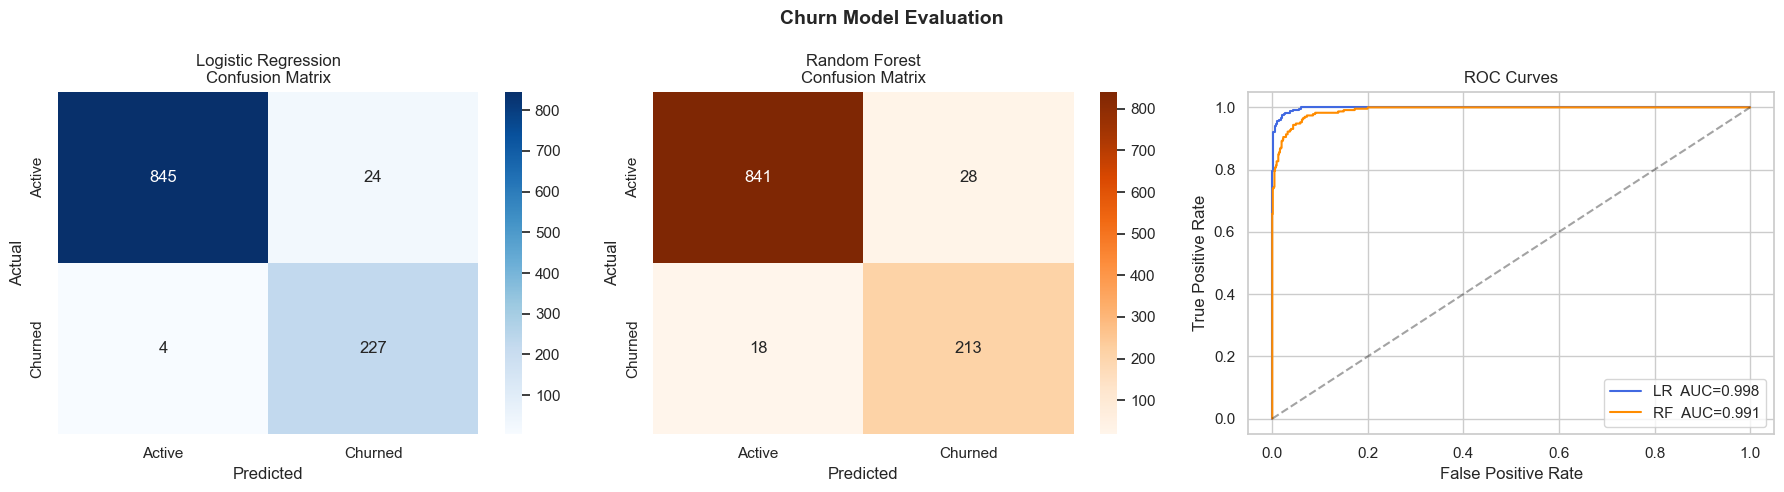

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Churn Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active','Churned'], yticklabels=['Active','Churned'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Active','Churned'], yticklabels=['Active','Churned'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[2].plot(fpr_lr, tpr_lr, label=f'LR  AUC={roc_auc_score(y_test,y_prob_lr):.3f}', color='royalblue')
axes[2].plot(fpr_rf, tpr_rf, label=f'RF  AUC={roc_auc_score(y_test,y_prob_rf):.3f}', color='darkorange')
axes[2].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[2].set_title('ROC Curves')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('../output/churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance — Random Forest

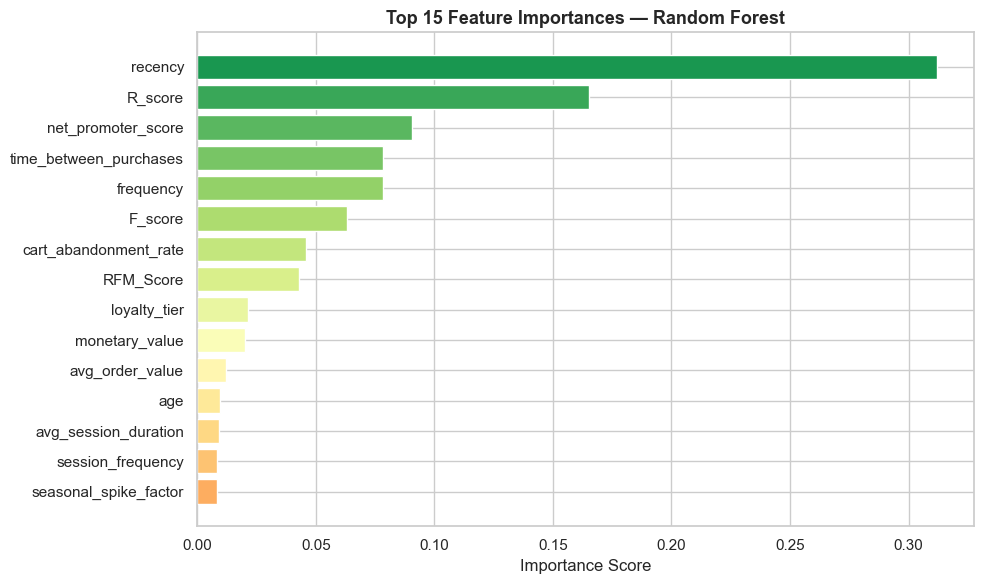

Top 5 most important features:
recency                   0.311987
R_score                   0.165405
net_promoter_score        0.090718
time_between_purchases    0.078552
frequency                 0.078486
dtype: float64


In [9]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
top_features = feat_imp.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))
ax.barh(top_features.index, top_features.values, color=colors_imp)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../output/churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 most important features:")
print(feat_imp.tail(5)[::-1])

## 10. Model Comparison

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9745     0.9044  0.9827    0.9419   0.9981
Random Forest          0.9582     0.8838  0.9221    0.9025   0.9912


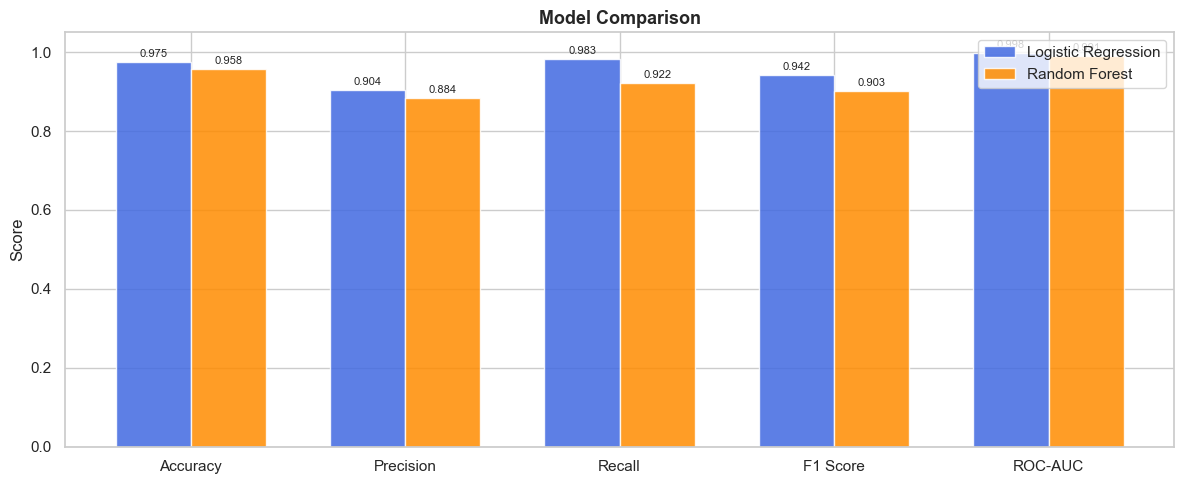

In [10]:
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall'   : [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 Score' : [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC'  : [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)],
}).set_index('Model')

print(results.round(4).to_string())

metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, results.loc['Logistic Regression', metrics], width,
       label='Logistic Regression', color='royalblue', alpha=0.85)
ax.bar(x + width/2, results.loc['Random Forest', metrics], width,
       label='Random Forest', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('../output/churn_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Models

In [11]:
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/scaler_churn.pkl', 'wb') as f:
    pickle.dump(scaler_churn, f)

with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('../models/churn_features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(" Saved:")
print("   models/logistic_regression.pkl")
print("   models/random_forest.pkl")
print("   models/scaler_churn.pkl")
print("   models/label_encoders.pkl")
print("   models/churn_features.pkl")

 Saved:
   models/logistic_regression.pkl
   models/random_forest.pkl
   models/scaler_churn.pkl
   models/label_encoders.pkl
   models/churn_features.pkl
